5 вариант

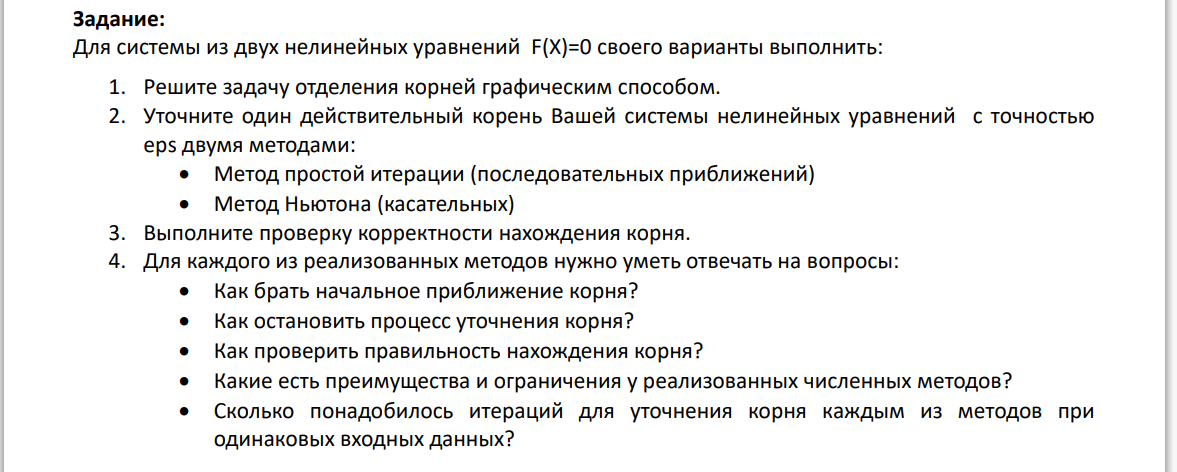

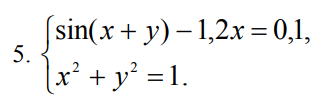

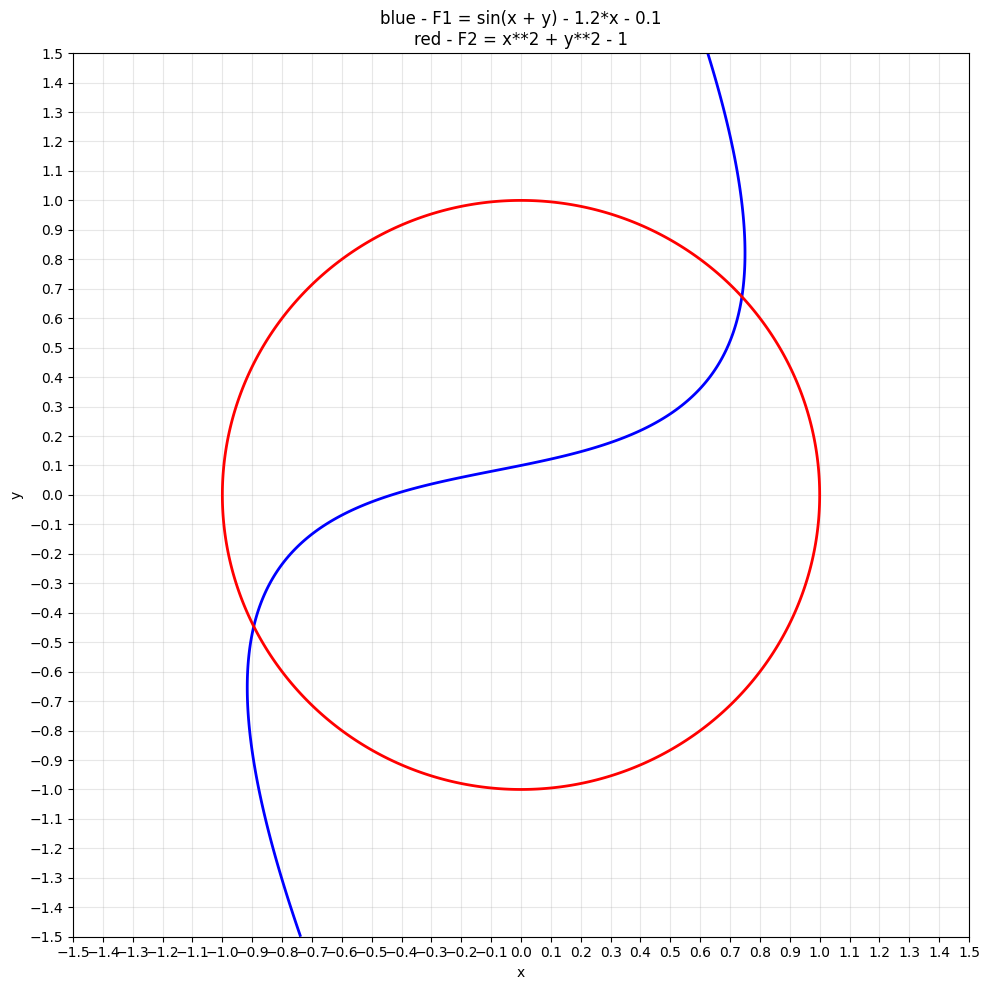

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import math

MAX_ITERS = 1000

def F(x):
    """F(x) = 0"""
    f1 = np.sin(x[0]+x[1]) - 1.2*x[0] - 0.1
    f2 = x[0]**2 + x[1]**2 - 1
    return np.array([f1,f2])


def grath():
    
    x = np.linspace(-1.5, 1.5,400)
    y = np.linspace(-1.5, 1.5,400)
    
    X, Y = np.meshgrid(x,y)
    
    F1 = np.sin(X + Y) - 1.2*X - 0.1
    F2 = X**2 + Y**2 - 1
    
    fig, ax = plt.subplots(figsize=(10,10))
    
    ax.contour(X, Y, F1, levels=[0], colors='blue', linewidths=2)    
    ax.contour(X, Y, F2, levels=[0], colors='red', linewidths=2)
    
    ax.set_xticks(np.arange(-1.5,1.6,0.1))
    ax.set_yticks(np.arange(-1.5,1.6,0.1))
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title("blue - F1 = sin(x + y) - 1.2*x - 0.1\nred - F2 = x**2 + y**2 - 1")
    ax.grid(True,alpha=0.3)
    ax.set_xlim([-1.5,1.5])
    ax.set_ylim([-1.5,1.5])
    
    plt.tight_layout()
    plt.show()
    
grath()
    

In [55]:
def simple_iters(x0,y0,eps):
    x, y = x0, y0
    iters = 0
    
    def phi1(x,y):
        return np.sqrt(max(0,1 - y**2))
    
    
    def phi2(x,y):
        return 0.5 * np.arcsin(0.1 + 0.8 * x) - 0.3 * x
    
    
    def dphi1_dx(x,y):
        return 0
    
    
    def dphi1_dy(x,y):
        val = 1 - y**2
        if val <= 0:
            return 0
        return -y / np.sqrt(val)
    
    
    def dphi2_dx(x,y):
        val = 0.1 + 0.8 * x 
        val = max(-1, min(1, val))
        return 1.2 / np.sqrt(1 - val**2) - 1
        

    def dphi2_dy(x,y):
        return 0
    
    a, b = 0.7, 0.75
    c, d = 0.6, 0.7
    
    print("   Проверка сходимости:")
    
    test_points = [
        (a, c), (a, d), (b, c), (b, d),
        ((a+b)/2, (c+d)/2),
        (x0, y0)
    ]
    
    q1_val = []
    q2_val = []
    
    for tp_x, tp_y in test_points:
        q1 = abs(dphi1_dx(tp_x, tp_y)) + abs(dphi1_dy(tp_x, tp_y))
        q2 = abs(dphi2_dx(tp_x, tp_y)) + abs(dphi2_dy(tp_x, tp_y))
        print(f"q1 = {q1}    q2 = {q2}")
        
        q1_val.append(q1)
        q2_val.append(q2)
        
    q1_max = max(q1_val)
    q2_max = max(q2_val)
    
    print(f"q1_max = {q1_max}\nq2_max = {q2_max}")
    
    print("\n   Итерационный процесс:")
    
    for iter in range(1000):
        x_old, y_old = x, y
        
        x_new = phi1(x_old,y_old)
        y_new = phi2(x_old,y_old)
        
        dx = abs(x_new - x_old)
        dy = abs(y_new - y_old)
        
        if iter < 5:
            print(f"Итерация = {iter:<4} x = {x_new:<10.10f} y = {y_new:<10.10f} dx = {dx:<10.10f} dy = {dy:<10.10f}")
        
        if max(dx, dy) < eps:
            print(f"\nКоличество итераций: {iter}")
            print(f"Точность: {max(dx, dy)}")
            print(f"x = {x_new:<10.10f} y = {y_new:<10.10f}")
            break
        
        x, y = x_new, y_new
        iter += 1
    
    print("\n   Проверка решения:") 
    
    f1 = phi1(x_new, y_new) - x_new 
    f2 = phi2(x_new, y_new) - y_new
    
    if abs(f1) < eps and abs(f2) < eps:
        print(f"Решение верно")
    else:
        print(f"Точность не достигнута для исходной системы")
    
    return x_new, y_new, iters
 

x0, y0 = 0.75, 0.66
simple_xo, simple_y0, simple_ites =  simple_iters(x0, y0, 1e-5)   
        

   Проверка сходимости:
q1 = 0.7499999999999999    q2 = 0.5973046041950061
q1 = 0.9801960588196068    q2 = 0.5973046041950061
q1 = 0.7499999999999999    q2 = 0.6803361008336117
q1 = 0.9801960588196068    q2 = 0.6803361008336117
q1 = 0.8553372034476995    q2 = 0.6366341767699426
q1 = 0.8785175323072534    q2 = 0.6803361008336117
q1_max = 0.9801960588196068
q2_max = 0.6803361008336117

   Итерационный процесс:
Итерация = 0    x = 0.7512655988 y = 0.1626987483 dx = 0.0012655988 dy = 0.4973012517
Итерация = 1    x = 0.9866757914 y = 0.1630284393 dx = 0.2354101925 dy = 0.0003296910
Итерация = 2    x = 0.9866213701 y = 0.2519478121 dx = 0.0000544213 dy = 0.0889193728
Итерация = 3    x = 0.9677408227 y = 0.2519165349 dx = 0.0188805474 dy = 0.0000312771
Итерация = 4    x = 0.9677489651 y = 0.2415630948 dx = 0.0000081424 dy = 0.0103534401

Количество итераций: 11
Точность: 6.098541903920562e-06
x = 0.9700771834 y = 0.2427967328

   Проверка решения:
Решение верно
